In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score,classification_report, confusion_matrix)
import joblib

In [3]:
x_train, x_test, y_train, y_test = joblib.load("train_test_splits.pkl")

In [4]:
models ={
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}
results = {}


In [5]:
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {"Accuracy": round(acc, 4), "AUC": round(auc, 4)}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}| AUC:{auc:.4f}")
    print(classification_report(y_test, y_pred))

    print("\n===Summary===")
    print(pd.DataFrame(results).T.sort_values('AUC', ascending=False))


Model: Logistic Regression
Accuracy: 0.7714| AUC:0.8638
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        94
           1       0.74      0.79      0.76        81

    accuracy                           0.77       175
   macro avg       0.77      0.77      0.77       175
weighted avg       0.77      0.77      0.77       175


===Summary===
                     Accuracy     AUC
Logistic Regression    0.7714  0.8638

Model: Random Forest
Accuracy: 0.7943| AUC:0.8834
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        94
           1       0.77      0.79      0.78        81

    accuracy                           0.79       175
   macro avg       0.79      0.79      0.79       175
weighted avg       0.79      0.79      0.79       175


===Summary===
                     Accuracy     AUC
Random Forest          0.7943  0.8834
Logistic Regression    0.7714  0.8638

Model: Gradient B

In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 4))

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred  = best_rf.predict(x_test)
y_proba = best_rf.predict_proba(x_test)[:, 1]

print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test AUC:     ", round(roc_auc_score(y_test, y_proba), 4))
print(classification_report(y_test, y_pred))

# Save tuned model
joblib.dump(best_rf, 'best_rf_model.pkl')
print("\nBest model saved.")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC: 0.8908

Test Accuracy: 0.8
Test AUC:      0.898
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        94
           1       0.79      0.78      0.78        81

    accuracy                           0.80       175
   macro avg       0.80      0.80      0.80       175
weighted avg       0.80      0.80      0.80       175


Best model saved.


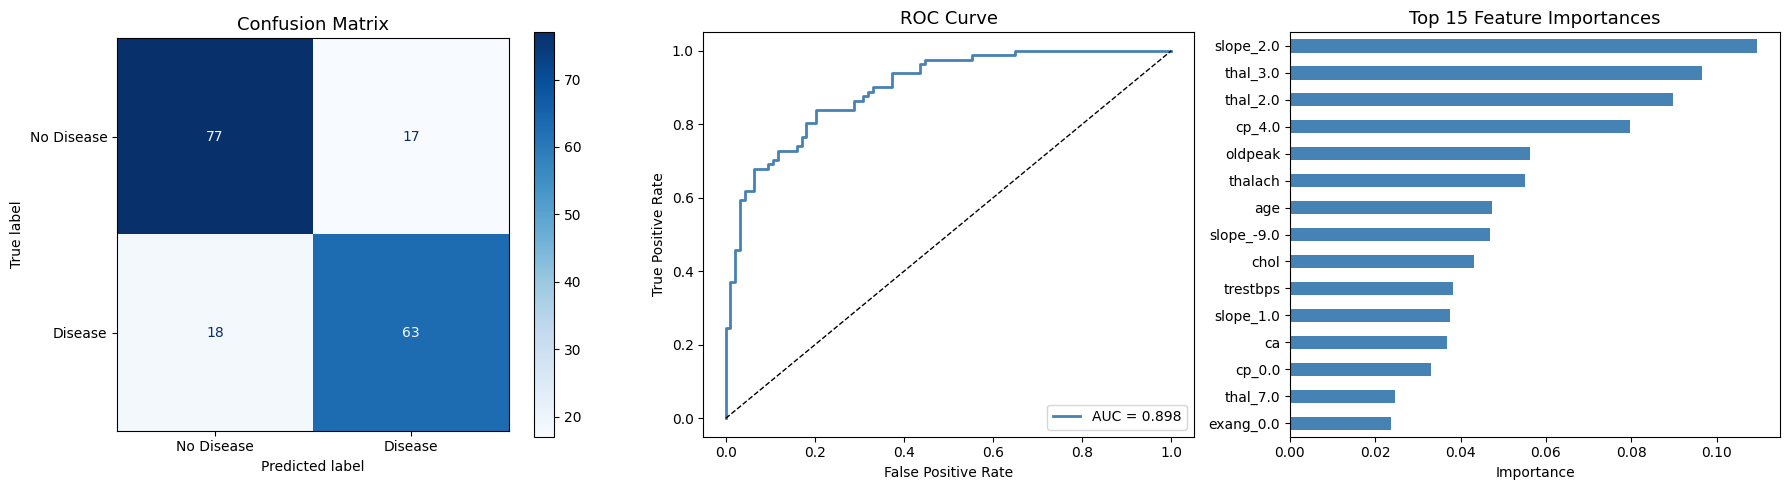

Plot saved.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

feature_cols = joblib.load('feature_columns.pkl')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion Matrix ─────────────────────────────────
ConfusionMatrixDisplay.from_estimator(
    best_rf, x_test, y_test,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=13)

# ── 2. ROC Curve ────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = 0.898')
axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')

# ── 3. Top 15 Feature Importances ───────────────────────
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=True).tail(15)

top15.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 15 Feature Importances', fontsize=13)
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [10]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred)

print("=" * 40)
print("      FINAL MODEL SUMMARY")
print("=" * 40)
print(f"  Model      : Random Forest (tuned)")
print(f"  Dataset    : {x_train.shape[0] + x_test.shape[0]} rows, {x_train.shape[1]} features")
print(f"  Accuracy   : 80.0%")
print(f"  AUC        : 0.898")
print(f"  MCC        : {mcc:.4f}")
print(f"  Precision  : 0.80 (macro)")
print(f"  Recall     : 0.80 (macro)")
print("=" * 40)

      FINAL MODEL SUMMARY
  Model      : Random Forest (tuned)
  Dataset    : 875 rows, 34 features
  Accuracy   : 80.0%
  AUC        : 0.898
  MCC        : 0.5975
  Precision  : 0.80 (macro)
  Recall     : 0.80 (macro)


In [4]:
from recommender import get_recommendations

# Simulate a high-risk patient
test_input = {
    'age':      62,
    'sex':      1,
    'trestbps': 145,
    'chol':     250,
    'fbs':      1,
    'thalach':  120,
    'exang':    1,
    'oldpeak':  2.5
}

result = get_recommendations(test_input, risk_score=0.813)

print(f"Risk Score : {result['risk_score']}%")
print(f"Risk Level : {result['risk_level']}")
print(f"Alert      : {result['alert']}")
print(f"\nRecommendations ({len(result['recommendations'])}):")
for r in result['recommendations']:
    print(f"  [{r['priority']}] {r['category']}: {r['action']}")

Risk Score : 81.3%
Risk Level : Critical
Alert      : Your risk score is critically high. Please consult a cardiologist immediately.

Recommendations (8):
  [High] Blood Pressure: Reduce sodium intake, avoid caffeine, do 30 min cardio 5x/week.
  [High] Cholesterol: Adopt a low-saturated-fat diet. Consult doctor about statins.
  [High] Blood Sugar: Reduce sugar and refined carbs. Get HbA1c tested. Consider diabetes screening.
  [High] Exercise Angina: Avoid strenuous exercise until cleared by a doctor. Track symptoms.
  [High] ST Depression: This indicates possible ischemia. Seek cardiology evaluation.
  [Medium] Heart Rate: Gradually increase aerobic activity. Start with 20 min walks daily.
  [Low] Age Risk: Schedule annual cardiac checkups. Stay physically active.
  [Low] Demographics: Regular screening recommended. Monitor BP and cholesterol annually.
